In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from scipy.interpolate import interp1d

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/gaia_dr9_reference.fits', rows=[0]))

RA,DEC,mask_mag,gaia_g,zguess,is_tycho2
float64,float64,float64,float64,float32,bool
225.18092722,-11.13401444,8.907500267028809,8.907500267028809,8.067661,True


In [4]:
gaia = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/useful/gaia_dr9_reference.fits'))
print(len(gaia))

41061828


-0.669127345085144 17.999998092651367


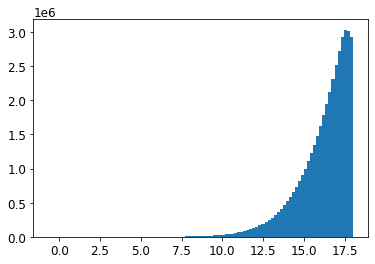

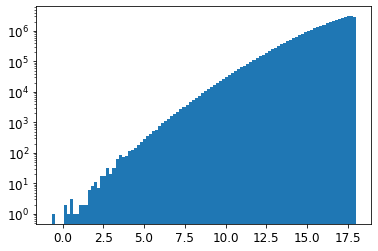

In [5]:
print(gaia['mask_mag'].min(), gaia['mask_mag'].max())

plt.hist(gaia['mask_mag'], 100)
plt.show()

plt.hist(gaia['mask_mag'], 100, log=True)
plt.show()

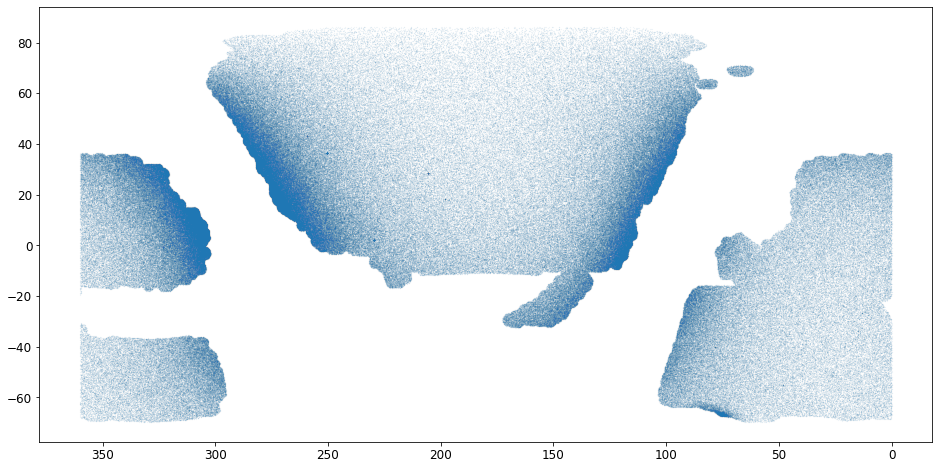

In [6]:
idx = np.random.choice(len(gaia), size=len(gaia)//50)
plt.figure(figsize=(16, 8))
plt.plot(gaia['RA'][idx], gaia['DEC'][idx], '.', ms=0.1, alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

-------
## DR9 mask

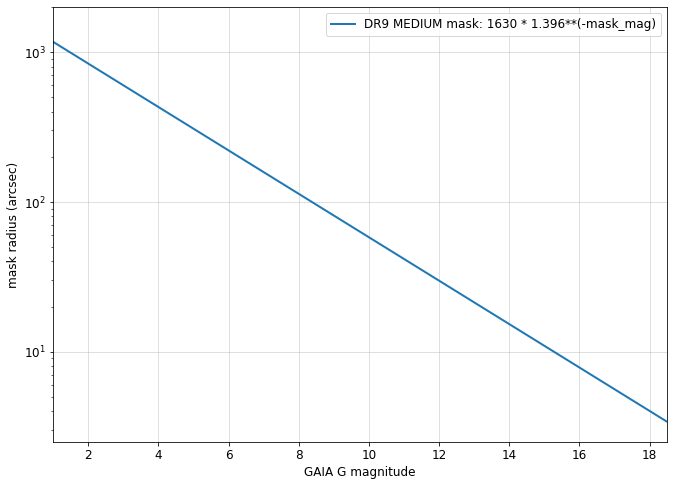

In [7]:
dr9_mag = np.linspace(0, 20, 1000)

# DR9 mask
dr9_radius = 1630 * 1.396**(-dr9_mag)

plt.figure(figsize=(11, 8))
plt.semilogy(dr9_mag, dr9_radius, '-', lw=2, label='DR9 MEDIUM mask: 1630 * 1.396**(-mask_mag)')
plt.grid(alpha=0.5)
plt.xlabel('GAIA G magnitude')
plt.ylabel('mask radius (arcsec)')
# plt.axhline(1800*0.262, lw=1, ls='--', color='k', label='maximum radius')
plt.axis([1., 18.5, 2.5, 2000])
plt.legend()
plt.show()

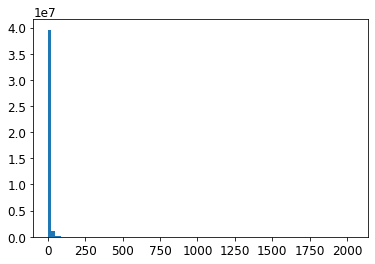

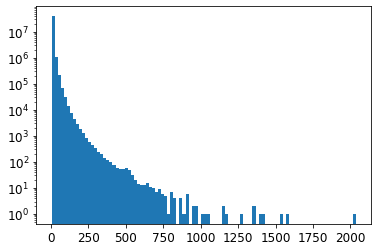

In [8]:
gaia['radius_dr9'] = 1630 * 1.396**(-gaia['mask_mag'])

plt.hist(gaia['radius_dr9'], 100)
plt.show()

plt.hist(gaia['radius_dr9'], 100, log=True)
plt.show()

In [9]:
mask_160 = gaia['mask_mag']<16

gaia_max_list = np.arange(8, 18.5, 0.5)
area_frac = np.zeros(len(gaia_max_list))
for index, gaia_max in enumerate(gaia_max_list):
    mask = gaia['mask_mag']<gaia_max
    area_frac[index] = np.sum(gaia['radius_dr9'][mask]**2)/np.sum(gaia['radius_dr9'][mask_160]**2)

In [10]:
# Raw masked area to G<16
np.sum(np.pi * gaia['radius_dr9'][mask_160]**2) / 3600**2

1357.5055633034976

In [11]:
# Raw masked area to G<18
np.sum(np.pi * gaia['radius_dr9']**2) / 3600**2

1559.331303767478

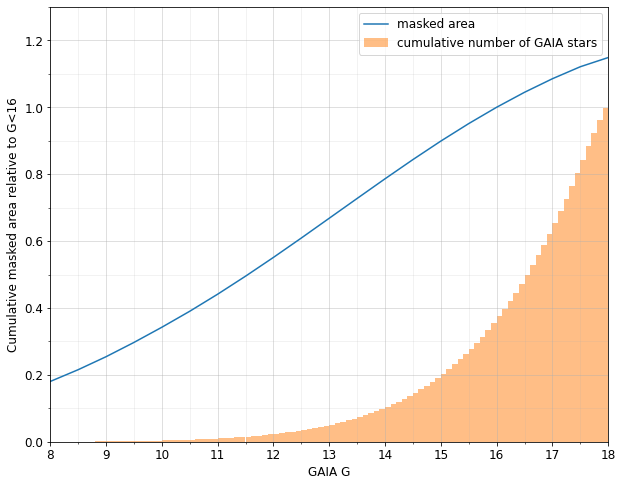

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(gaia_max_list, area_frac, label='masked area')
ax.set_xlabel('GAIA G')
ax.set_ylabel('Cumulative masked area relative to G<16')
ax.hist(gaia['mask_mag'], cumulative=True, range=(8, 18), bins=100, alpha=0.5, label='cumulative number of GAIA stars',
        weights=np.ones(len(gaia['mask_mag']))/len(gaia['mask_mag'])*1.)
ax.legend()

x_major_ticks = np.arange(0, 21, 1)
x_minor_ticks = np.arange(0, 21, 0.5)
y_major_ticks = np.arange(0, 2.1, 0.2)
y_minor_ticks = np.arange(0, 2.1, 0.1)

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')

# Or if you want different settings for the grids:
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

ax.axis([8, 18, 0, 1.3])

plt.show()

-------
## New mask - south

In [13]:
# mags = np.array([4.0, 9.0, 10.0, 10.5, 11.5, 12.0, 12.5, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 17.0, 18.0])
# radii_factor = np.array([1.0, 1.0, 1.0, 0.75, 0.75, 0.85, 0.85, 0.85, 0.9, 1.05, 1.1, 1.20, 1.25, 1.25, 1.25])
# radii = radii_factor * 1630 * 1.396**(-mags)

max_mag = 18.
mags = np.array([4.0, 9.0, 10.0, 10.5, 11.5, 12.0, 12.5, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 17.0, 18.0])
radii = np.array([429.18637985, 80.95037032, 57.98737129, 36.80882682,
        26.36735446, 25.29190318, 21.40616169, 15.33392671,
        13.74150366, 13.56870306, 12.03092488, 11.10823009,
         9.79334208, 7.01528803, 5.02527796])

log_radii = np.log10(radii)
f_radius_log_south = interp1d(mags, log_radii, bounds_error=False, fill_value='extrapolate')
f_radius_south = lambda mags: 10**f_radius_log_south(mags)

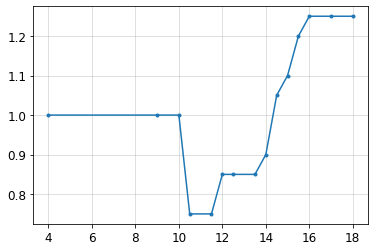

In [14]:
radii_factor = radii / (1630 * 1.396**(-mags))
plt.plot(mags, radii_factor, '.-')
plt.grid(alpha=0.5)
plt.show()

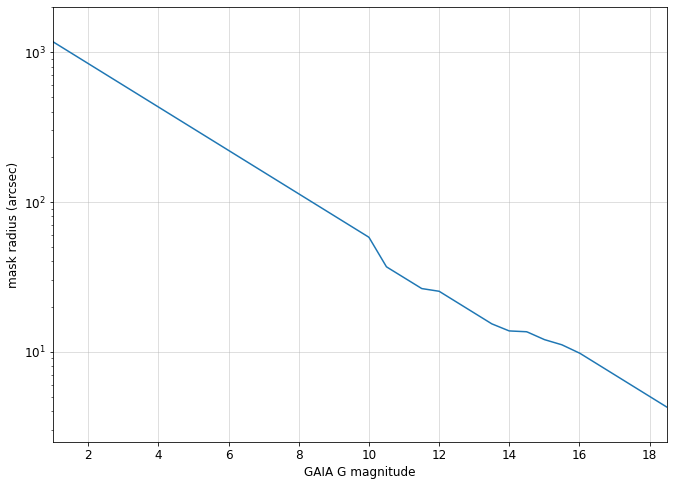

In [16]:
mags_plot = np.linspace(0, 19, 1000)

plt.figure(figsize=(11, 8))
plt.plot(mags_plot, f_radius_south(mags_plot))
plt.yscale('log')
plt.grid(alpha=0.5)
plt.xlabel('GAIA G magnitude')
plt.ylabel('mask radius (arcsec)')
# plt.axhline(1800*0.262, lw=1, ls='--', color='k', label='maximum radius')
plt.axis([1., 18.5, 2.5, 2000])
plt.show()

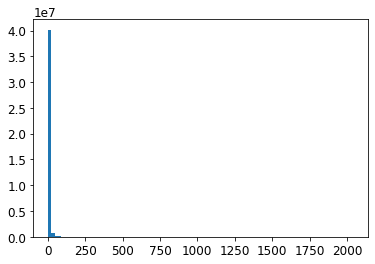

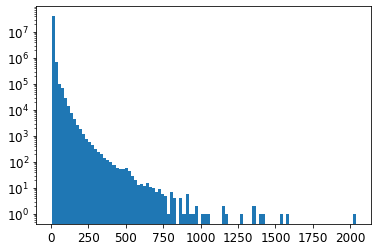

In [17]:
gaia['radius'] = 0.
mask = gaia['mask_mag']<max_mag
gaia['radius'][mask] = f_radius_south(gaia['mask_mag'][mask])

plt.hist(gaia['radius'], 100)
plt.show()

plt.hist(gaia['radius'], 100, log=True)
plt.show()

In [18]:
mask_160 = gaia['mask_mag']<16

# Raw masked area to G<16
print(np.sum(np.pi * gaia['radius'][mask_160]**2) / 3600**2)

# Raw masked area to G<18
print(np.sum(np.pi * gaia['radius']**2) / 3600**2)

1230.399231069926
1545.751950733736


In [19]:
gaia_max_list = np.arange(8, 18.5, 0.5)
area_frac = np.zeros(len(gaia_max_list))
for index, gaia_max in enumerate(gaia_max_list):
    mask = gaia['mask_mag']<gaia_max
    area_frac[index] = np.sum(gaia['radius'][mask]**2)/np.sum(gaia['radius'][mask_160]**2)

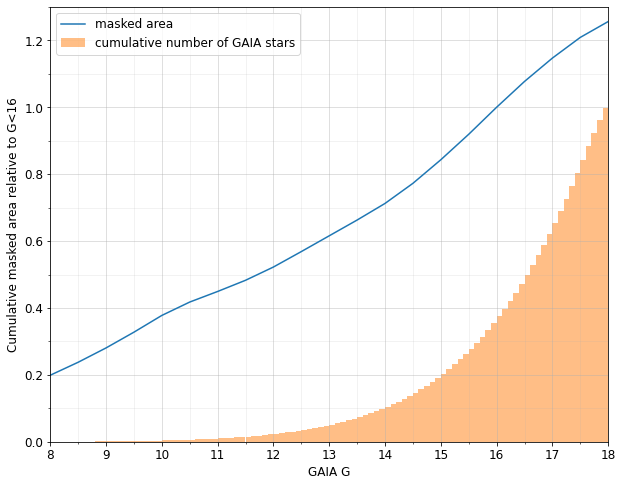

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(gaia_max_list, area_frac, label='masked area')
ax.set_xlabel('GAIA G')
ax.set_ylabel('Cumulative masked area relative to G<16')
ax.hist(gaia['mask_mag'], cumulative=True, range=(8, 18), bins=100, alpha=0.5, label='cumulative number of GAIA stars',
        weights=np.ones(len(gaia['mask_mag']))/len(gaia['mask_mag'])*1.)
ax.legend()

x_major_ticks = np.arange(0, 21, 1)
x_minor_ticks = np.arange(0, 21, 0.5)
y_major_ticks = np.arange(0, 2.1, 0.2)
y_minor_ticks = np.arange(0, 2.1, 0.1)

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')

# Or if you want different settings for the grids:
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

ax.axis([8, 18, 0, 1.3])

plt.show()

-------
## New mask - north

In [21]:
# max_mag = 18.
# mags = np.array([4.0, 9.0, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 17.0, 18.0])
# radii_factor = np.array([1.0, 1.0, 1.0, 1.2, 1.4, 1.35, 1.3, 1.3, 1.3, 1.3, 1.3, 1.3, 1.25, 1.25, 1.0, 1.0, 1.0])
# log_radii = np.log10(radii_factor * 1630 * 1.396**(-mags))
# print(10**log_radii)

# radii = 10**log_radii
# radii[2:5] = 60.
# log_radii = np.log10(radii)

# f_radius_log_north = interp1d(mags, log_radii, bounds_error=False, fill_value='extrapolate')
# f_radius_north = lambda mags: 10**f_radius_log_north(mags)

In [22]:
max_mag = 18.
mags = np.array([4.0, 9.0, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 17.0, 18.0])
radii = np.array([429.18637985, 80.95037032, 60., 60.,
        60., 47.46123803, 38.68173428, 32.73883553,
        27.70897871, 23.45188791, 19.84883862, 16.79934664,
        13.67150555, 11.57107301, 7.83467367, 5.61223042,
         4.02022236])

log_radii = np.log10(radii)
f_radius_log_north = interp1d(mags, log_radii, bounds_error=False, fill_value='extrapolate')
f_radius_north = lambda mags: 10**f_radius_log_north(mags)

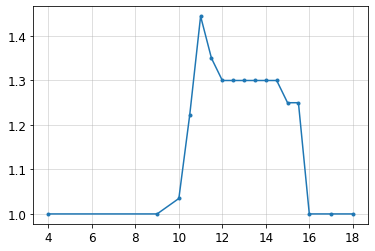

In [23]:
radii_factor = radii / (1630 * 1.396**(-mags))
plt.plot(mags, radii_factor, '.-')
plt.grid(alpha=0.5)
plt.show()

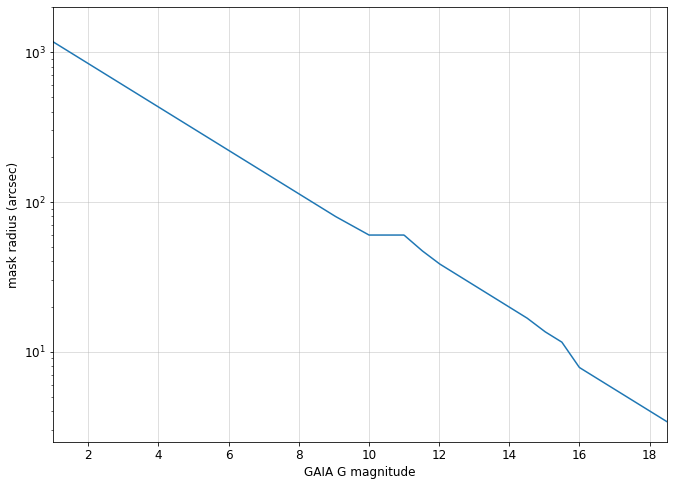

In [24]:
mags_plot = np.linspace(0, 19, 1000)

plt.figure(figsize=(11, 8))
plt.plot(mags_plot, f_radius_north(mags_plot))
plt.yscale('log')
plt.grid(alpha=0.5)
plt.xlabel('GAIA G magnitude')
plt.ylabel('mask radius (arcsec)')
# plt.axhline(1800*0.262, lw=1, ls='--', color='k', label='maximum radius')
plt.axis([1., 18.5, 2.5, 2000])
plt.show()

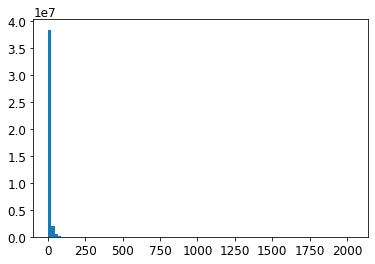

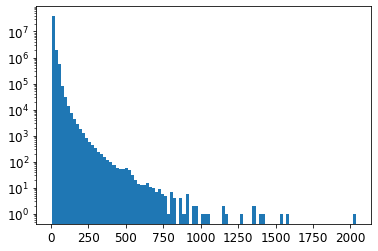

In [25]:
gaia['radius'] = 0.
mask = gaia['mask_mag']<max_mag
gaia['radius'][mask] = f_radius_north(gaia['mask_mag'][mask])

plt.hist(gaia['radius'], 100)
plt.show()

plt.hist(gaia['radius'], 100, log=True)
plt.show()

In [26]:
mask_160 = gaia['mask_mag']<16

# Raw masked area to G<16
print(np.sum(np.pi * gaia['radius'][mask_160]**2) / 3600**2)

# Raw masked area to G<18
print(np.sum(np.pi * gaia['radius']**2) / 3600**2)

1938.6032965890975
2140.4290369628643


In [27]:
mask_160 = gaia['mask_mag']<16

# Raw masked area to G<16
print(np.sum(np.pi * gaia['radius'][mask_160]**2) / 3600**2)

# Raw masked area to G<18
print(np.sum(np.pi * gaia['radius']**2) / 3600**2)

1938.6032965890975
2140.4290369628643


In [28]:
gaia_max_list = np.arange(8, 18.5, 0.5)
area_frac = np.zeros(len(gaia_max_list))
for index, gaia_max in enumerate(gaia_max_list):
    mask = gaia['mask_mag']<gaia_max
    area_frac[index] = np.sum(gaia['radius'][mask]**2)/np.sum(gaia['radius'][mask_160]**2)

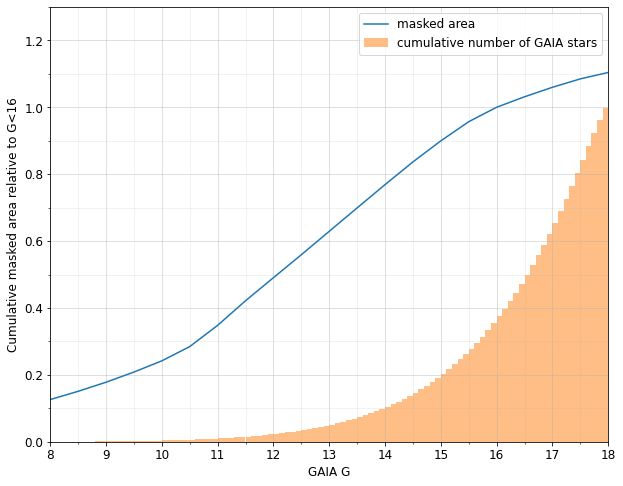

In [29]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(gaia_max_list, area_frac, label='masked area')
ax.set_xlabel('GAIA G')
ax.set_ylabel('Cumulative masked area relative to G<16')
ax.hist(gaia['mask_mag'], cumulative=True, range=(8, 18), bins=100, alpha=0.5, label='cumulative number of GAIA stars',
        weights=np.ones(len(gaia['mask_mag']))/len(gaia['mask_mag'])*1.)
ax.legend()

x_major_ticks = np.arange(0, 21, 1)
x_minor_ticks = np.arange(0, 21, 0.5)
y_major_ticks = np.arange(0, 2.1, 0.2)
y_minor_ticks = np.arange(0, 2.1, 0.1)

ax.set_xticks(x_major_ticks)
ax.set_xticks(x_minor_ticks, minor=True)
ax.set_yticks(y_major_ticks)
ax.set_yticks(y_minor_ticks, minor=True)

# And a corresponding grid
ax.grid(which='both')

# Or if you want different settings for the grids:
ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

ax.axis([8, 18, 0, 1.3])

plt.show()

------

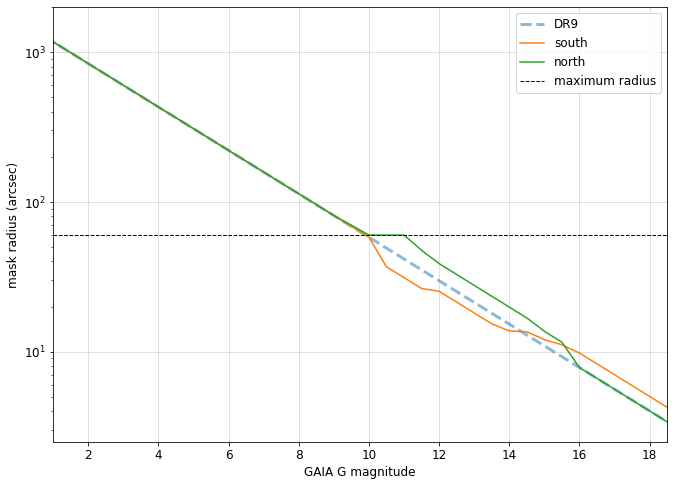

In [34]:
mags_plot = np.linspace(0, 19, 1000)

plt.figure(figsize=(11, 8))
plt.plot(dr9_mag, dr9_radius, label='DR9', lw=3, ls='--', alpha=0.5)
plt.plot(mags_plot, f_radius_south(mags_plot), label='south')
plt.plot(mags_plot, f_radius_north(mags_plot), label='north')
plt.yscale('log')
plt.grid(alpha=0.5)
plt.xlabel('GAIA G magnitude')
plt.ylabel('mask radius (arcsec)')
# plt.axhline(60, lw=1, ls='--', color='k', label='maximum radius')
plt.axis([1., 18.5, 2.5, 2000])
plt.legend()
plt.show()